# Floruit periods — how each individual was dated, and at what age people were considered to be flourishing.

In [1]:
import re
import random
from pathlib import Path

import numpy as np
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DB_PATH = '../../data/humans_clean.duckdb'
CV_PATH = '../../data/similar_databases/cross-verified-database/cross-verified-database.utf8.csv.gz'

COLORS = {
    'floruit':         '#7e1d1d',
    'birth_and_death': '#c44e4e',
    'birth_only':      '#e08e3a',
    'works':           '#3a8fbf',
    'century_only':    '#1f4f7a',
    'no_data':         '#9aa0a6',
    'iqr_band':        '#3a8fbf',
    'median_line':     '#1f4f7a',
}

OCCUPATION_COLORS = {
    'Culture':           '#7e1d1d',
    'Discovery/Science': '#3a8fbf',
    'Leadership':        '#e08e3a',
    'Sports/Games':      '#1f4f7a',
}

ERA_COLORS = {
    'before 500':  '#7e1d1d',
    '500 – 1500':  '#c44e4e',
    '1500 – 1800': '#e08e3a',
    '1800 – 1900': '#3a8fbf',
    'after 1900':  '#1f4f7a',
}

plt.rcParams.update({
    'figure.dpi':       120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'legend.fontsize':   11,
})


## Connect

In [2]:
con = duckdb.connect(DB_PATH, read_only=True)


## Floruit period rows  (one row per individual: method + floruit window + birth/death years)

In [ ]:
floruit_rows = con.execute("""
    SELECT  wikidata_id,
            name_en,
            method,
            birth_year,
            death_year,
            floruit_year,
            floruit_date
    FROM    individuals_floruit_period
    WHERE   method IS NOT NULL
""").pl()

print('shape:', floruit_rows.shape)
floruit_rows.head()


## Method category  (6 broad groups)

In [4]:
method_rows = (
    floruit_rows
    .with_columns(
        pl.when(pl.col('method').str.starts_with('floruit_'))
          .then(pl.lit('Floruit (P1317)'))
        .when(pl.col('method').str.ends_with('_century'))
          .then(pl.lit('Century-only'))
        .when(pl.col('method').str.starts_with('birth_death_'))
          .then(pl.lit('Birth + death'))
        .when(pl.col('method').str.starts_with('birth_only_'))
          .then(pl.lit('Birth only'))
        .when(pl.col('method').str.starts_with('works_'))
          .then(pl.lit('Works dates'))
        .when(pl.col('method').is_in(['no_data', 'under_30']))
          .then(pl.lit('No data / under 30'))
        .otherwise(pl.lit('Other'))
        .alias('method_category')
    )
)

print('shape:', method_rows.shape)
print(method_rows.group_by('method_category').len().sort('len', descending=True))
method_rows.head()


shape: (13003420, 11)
shape: (6, 2)
┌────────────────────┬─────────┐
│ method_category    ┆ len     │
│ ---                ┆ ---     │
│ str                ┆ u32     │
╞════════════════════╪═════════╡
│ Birth only         ┆ 3509463 │
│ No data / under 30 ┆ 3319606 │
│ Birth + death      ┆ 3244970 │
│ Works dates        ┆ 2754205 │
│ Century-only       ┆ 90223   │
│ Floruit (P1317)    ┆ 84953   │
└────────────────────┴─────────┘


wikidata_id,name_en,method,birth_year,death_year,floruit_year,floruit_period,floruit_period_start,floruit_period_end,floruit_precision,method_category
str,str,str,i64,i64,i64,str,i64,i64,i64,str
"""Q101553124""","""Moharram Eslami""","""works_single""",null,null,null,"""2015-2026""",2015,2026,null,"""Works dates"""
"""Q101553254""","""Alie Kord Zaferanloo Kambuziya""","""no_data""",null,null,null,null,null,null,null,"""No data / under 30"""
"""Q101553398""","""SubVerso""","""birth_only_property""",1975,null,null,"""2005-2026""",2005,2026,null,"""Birth only"""
"""Q101553548""","""Achim Bednorz""","""birth_only_property""",1947,null,null,"""1977-2002""",1977,2002,null,"""Birth only"""
"""Q101553561""","""Peter Lind""","""no_data""",null,null,null,null,null,null,null,"""No data / under 30"""


## Fig 1 — Floruit-method category counts

In [5]:
METHOD_CATEGORY_ORDER = [
    'Floruit (P1317)',
    'Birth + death',
    'Birth only',
    'Works dates',
    'Century-only',
    'No data / under 30',
]
METHOD_CATEGORY_COLORS = {
    'Floruit (P1317)':     COLORS['floruit'],
    'Birth + death':       COLORS['birth_and_death'],
    'Birth only':          COLORS['birth_only'],
    'Works dates':         COLORS['works'],
    'Century-only':        COLORS['century_only'],
    'No data / under 30':  COLORS['no_data'],
}

method_counts = (
    method_rows
    .group_by('method_category').len()
    .with_columns(
        (pl.col('len') / method_rows.height * 100).round(2).alias('share_pct')
    )
)

print('shape:', method_counts.shape)
method_counts.sort('len', descending=True)


shape: (6, 3)


method_category,len,share_pct
str,u32,f64
"""Birth only""",3509463,26.99
"""No data / under 30""",3319606,25.53
"""Birth + death""",3244970,24.95
"""Works dates""",2754205,21.18
"""Century-only""",90223,0.69
"""Floruit (P1317)""",84953,0.65


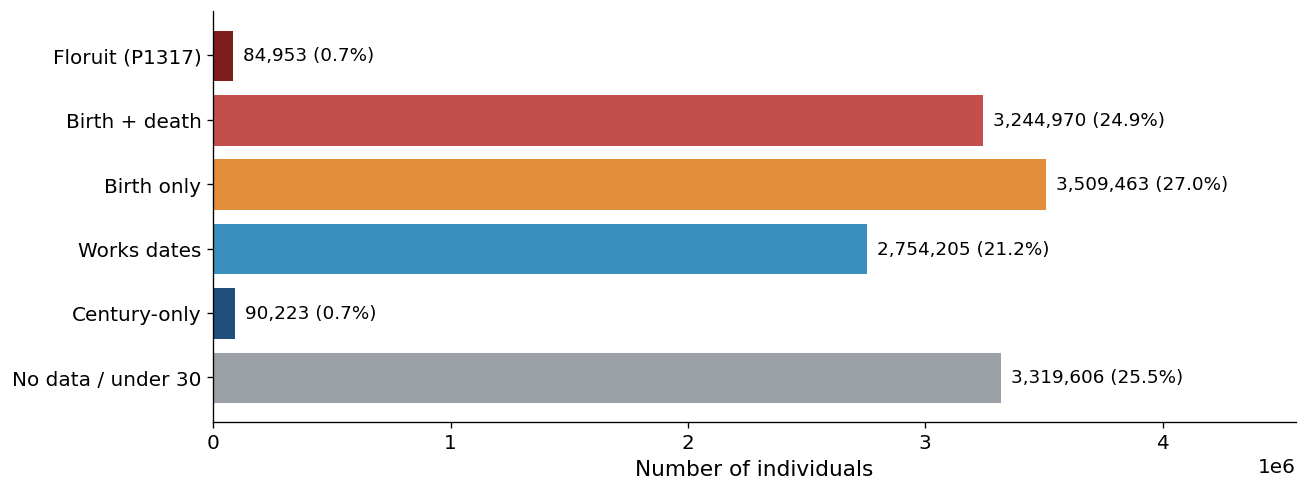

In [6]:
ordered_for_plot = list(reversed(METHOD_CATEGORY_ORDER))
counts_for_plot = (
    pl.DataFrame({'method_category': ordered_for_plot})
    .join(method_counts, on='method_category', how='left')
    .with_columns(
        pl.col('len').fill_null(0).cast(pl.Int64),
        pl.col('share_pct').fill_null(0.0),
    )
)

labels   = counts_for_plot['method_category'].to_list()
ns       = counts_for_plot['len'].to_list()
shares   = counts_for_plot['share_pct'].to_list()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.barh(
    labels, ns,
    color=[METHOD_CATEGORY_COLORS[l] for l in labels],
    edgecolor='white', linewidth=0.6,
)
for y, (n, share) in enumerate(zip(ns, shares)):
    ax.annotate(f'{n:,} ({share:.1f}%)', xy=(n, y),
                xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=11)
ax.set_xlabel('Number of individuals')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.margins(x=0.30)
plt.tight_layout()
plt.show()


## Method category by century  (share over time)

In [ ]:
CENTURY_BIN  = 100
YEAR_MIN     = -800
YEAR_MAX     = 2000

method_by_century = (
    method_rows
    .filter(pl.col('floruit_year').is_between(YEAR_MIN, YEAR_MAX))
    .with_columns(((pl.col('floruit_year') // CENTURY_BIN) * CENTURY_BIN).alias('century'))
    .group_by('century', 'method_category').len()
    .pivot(values='len', index='century', on='method_category', aggregate_function='sum')
    .fill_null(0)
    .sort('century')
)
for category in METHOD_CATEGORY_ORDER:
    if category not in method_by_century.columns:
        method_by_century = method_by_century.with_columns(pl.lit(0).alias(category))
method_by_century = method_by_century.select(['century'] + METHOD_CATEGORY_ORDER)

print('shape:', method_by_century.shape)
method_by_century.head()


## Fig 2 — Method category share by century

In [ ]:
centuries = method_by_century['century'].to_list()
totals = np.array([sum(method_by_century[c][i] for c in METHOD_CATEGORY_ORDER) for i in range(len(centuries))], dtype=float)
totals_safe = np.where(totals == 0, np.nan, totals)

shares = np.zeros((len(centuries), len(METHOD_CATEGORY_ORDER)))
for j, category in enumerate(METHOD_CATEGORY_ORDER):
    shares[:, j] = method_by_century[category].to_numpy() / totals_safe
shares = np.nan_to_num(shares)

xs = np.arange(len(centuries))
fig, ax = plt.subplots(figsize=(13, 4.6))
bottoms = np.zeros(len(centuries))
for j, category in enumerate(METHOD_CATEGORY_ORDER):
    ax.bar(xs, shares[:, j], bottom=bottoms, width=0.95,
           color=METHOD_CATEGORY_COLORS[category],
           edgecolor='white', linewidth=0.3, label=category)
    bottoms = bottoms + shares[:, j]

label_centuries = {c for c in centuries if c % 200 == 0}
label_centuries.update({centuries[0], centuries[-1]})
xt  = [i for i, c in enumerate(centuries) if c in label_centuries]
xtl = [str(centuries[i]) for i in xt]
ax.set_xticks(xt)
ax.set_xticklabels(xtl, rotation=45, ha='right')
ax.set_ylim(0, 1)
ax.set_xlim(-0.5, len(centuries) - 0.5)
ax.set_ylabel('Share of individuals')
ax.set_xlabel('Floruit year (century bins)')
ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


## Worked examples — 5 individuals per method category

In [ ]:
WORKED_EXAMPLES_PER_CATEGORY = 5

worked_examples = pl.concat([
    method_rows
        .filter(pl.col('method_category') == category)
        .filter(pl.col('name_en').is_not_null())
        .sample(n=min(WORKED_EXAMPLES_PER_CATEGORY,
                      method_rows.filter(pl.col('method_category') == category).height),
                seed=SEED)
    for category in METHOD_CATEGORY_ORDER
])

print('shape:', worked_examples.shape)
worked_examples.select(['method_category', 'method', 'wikidata_id', 'name_en',
                        'birth_year', 'death_year', 'floruit_year', 'floruit_date'])


## Floruit + birth pairs  (for age-at-floruit analysis)

In [ ]:
floruit_birth_pairs = con.execute("""
    SELECT  individuals_floruit_period.wikidata_id,
            individuals_floruit_period.floruit_year,
            individuals.birthdate
    FROM       individuals_floruit_period
    JOIN       individuals USING (wikidata_id)
    WHERE      individuals_floruit_period.floruit_year IS NOT NULL
      AND      individuals.birthdate IS NOT NULL
""").pl()

print('shape:', floruit_birth_pairs.shape)
floruit_birth_pairs.head()


## Age at floruit  (Polars: parse birth year, compute age, filter plausible)

In [11]:
AGE_MIN = 10
AGE_MAX = 100

YEAR_PATTERN = r'^(-?)(\d+)'

def signed_year(s):
    if not isinstance(s, str):
        return None
    m = re.match(YEAR_PATTERN, s.strip())
    if not m:
        return None
    year = int(m.group(2))
    return -year if m.group(1) == '-' else year

age_at_floruit = (
    floruit_birth_pairs
    .with_columns(
        pl.col('birthdate').map_elements(signed_year, return_dtype=pl.Int64).alias('birth_year')
    )
    .drop_nulls(['birth_year'])
    .with_columns(
        (pl.col('floruit_year') - pl.col('birth_year')).alias('age_at_floruit')
    )
    .filter((pl.col('age_at_floruit') >= AGE_MIN) & (pl.col('age_at_floruit') <= AGE_MAX))
)

print('shape:', age_at_floruit.shape)
age_at_floruit.head()


shape: (17042, 6)


wikidata_id,floruit_year,floruit_precision,birthdate,birth_year,age_at_floruit
str,i64,i64,str,i64,i64
"""Q106644109""",1850,9,"""1816-01-19""",1816,34
"""Q106644110""",1973,9,"""1952-01-01""",1952,21
"""Q106644111""",1755,9,"""1692-01-01""",1692,63
"""Q106644112""",1967,9,"""1938-01-01""",1938,29
"""Q106644113""",1968,9,"""1913-01-01""",1913,55


## Fig 3 — Age-at-floruit distribution by historical era

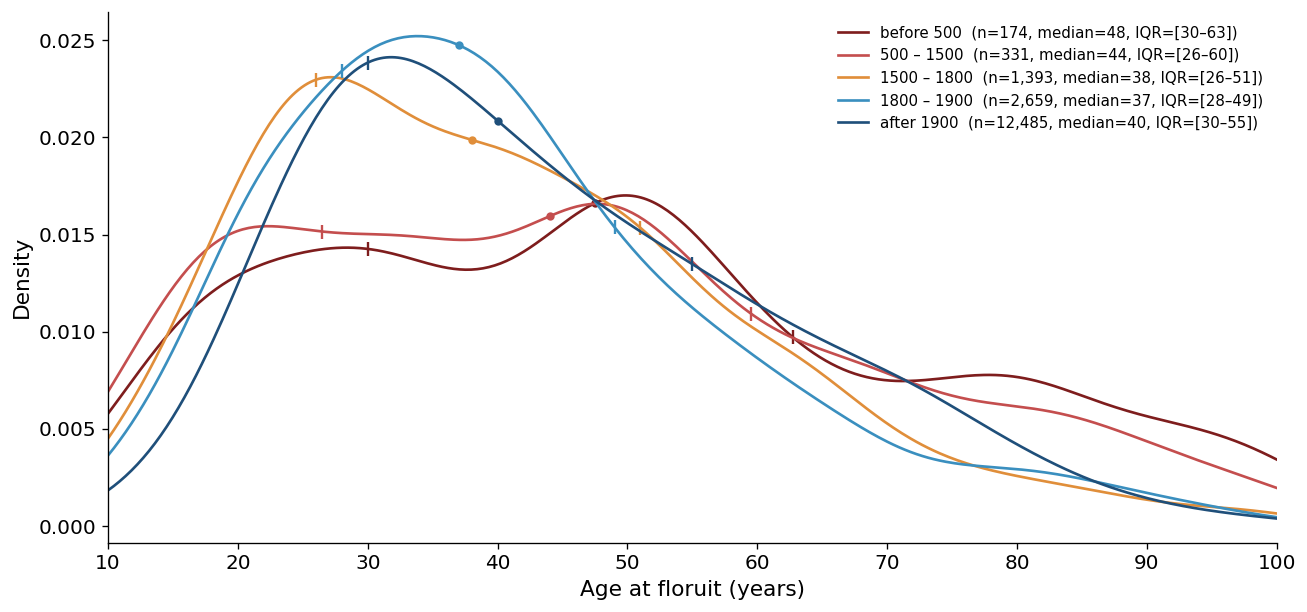

In [12]:
ERAS = [
    ('before 500',     None,  500),
    ('500 – 1500',      500, 1500),
    ('1500 – 1800',    1500, 1800),
    ('1800 – 1900',    1800, 1900),
    ('after 1900',     1900, None),
]
KDE_BANDWIDTH = 0.25
KDE_GRID_POINTS = 400

x_grid = np.linspace(AGE_MIN, AGE_MAX, KDE_GRID_POINTS)

fig, ax = plt.subplots(figsize=(11, 5.2))
for era_label, lo, hi in ERAS:
    sub_filter = pl.lit(True)
    if lo is not None:
        sub_filter = sub_filter & (pl.col('floruit_year') >= lo)
    if hi is not None:
        sub_filter = sub_filter & (pl.col('floruit_year') < hi)
    sub = age_at_floruit.filter(sub_filter)['age_at_floruit'].to_numpy()
    if len(sub) < 5:
        continue
    color = ERA_COLORS[era_label]
    kde = gaussian_kde(sub, bw_method=KDE_BANDWIDTH)
    y = kde(x_grid)
    median   = float(np.median(sub))
    quartile_low  = float(np.quantile(sub, 0.25))
    quartile_high = float(np.quantile(sub, 0.75))
    ax.plot(x_grid, y, color=color, lw=1.6,
            label=f'{era_label}  (n={len(sub):,}, median={median:.0f}, IQR=[{quartile_low:.0f}–{quartile_high:.0f}])')
    ax.plot([median], [kde(median)[0]], 'o', color=color, markersize=4)
    ax.plot([quartile_low, quartile_high],
            [kde(quartile_low)[0], kde(quartile_high)[0]],
            '|', color=color, markersize=8, markeredgewidth=1.4)

ax.set_xlim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()


## Cross-verified occupation table

In [13]:
cv_occupations = (
    pl.read_csv(
        CV_PATH,
        columns=['wikidata_code', 'level1_main_occ'],
        schema_overrides={'wikidata_code': pl.Utf8, 'level1_main_occ': pl.Utf8},
    )
    .drop_nulls(['wikidata_code', 'level1_main_occ'])
    .rename({'wikidata_code': 'wikidata_id'})
)

print('shape:', cv_occupations.shape)
cv_occupations.head()


shape: (2291817, 2)


wikidata_id,level1_main_occ
str,str
"""Q1000002""","""Culture"""
"""Q1000005""","""Culture"""
"""Q1000006""","""Culture"""
"""Q1000015""","""Culture"""
"""Q1000023""","""Leadership"""


## Age at floruit joined to CV occupations

In [14]:
SHOW_OCCUPATIONS = ['Culture', 'Discovery/Science', 'Leadership', 'Sports/Games']

age_at_floruit_by_occupation = (
    age_at_floruit
    .join(cv_occupations, on='wikidata_id', how='inner')
    .filter(pl.col('level1_main_occ').is_in(SHOW_OCCUPATIONS))
)

print('shape:', age_at_floruit_by_occupation.shape)
age_at_floruit_by_occupation.head()


shape: (4385, 7)


wikidata_id,floruit_year,floruit_precision,birthdate,birth_year,age_at_floruit,level1_main_occ
str,i64,i64,str,i64,i64,str
"""Q100116""",1698,9,"""1654-11-09""",1654,44,"""Culture"""
"""Q100289""",1900,9,"""1862-01-11""",1862,38,"""Culture"""
"""Q100432""",1912,9,"""1851-09-22""",1851,61,"""Culture"""
"""Q1007850""",2007,9,"""1941-06-17""",1941,66,"""Culture"""
"""Q100910""",1659,9,"""1627-02-18""",1627,32,"""Culture"""


## Fig 4 — Age-at-floruit distribution by cross-verified occupation

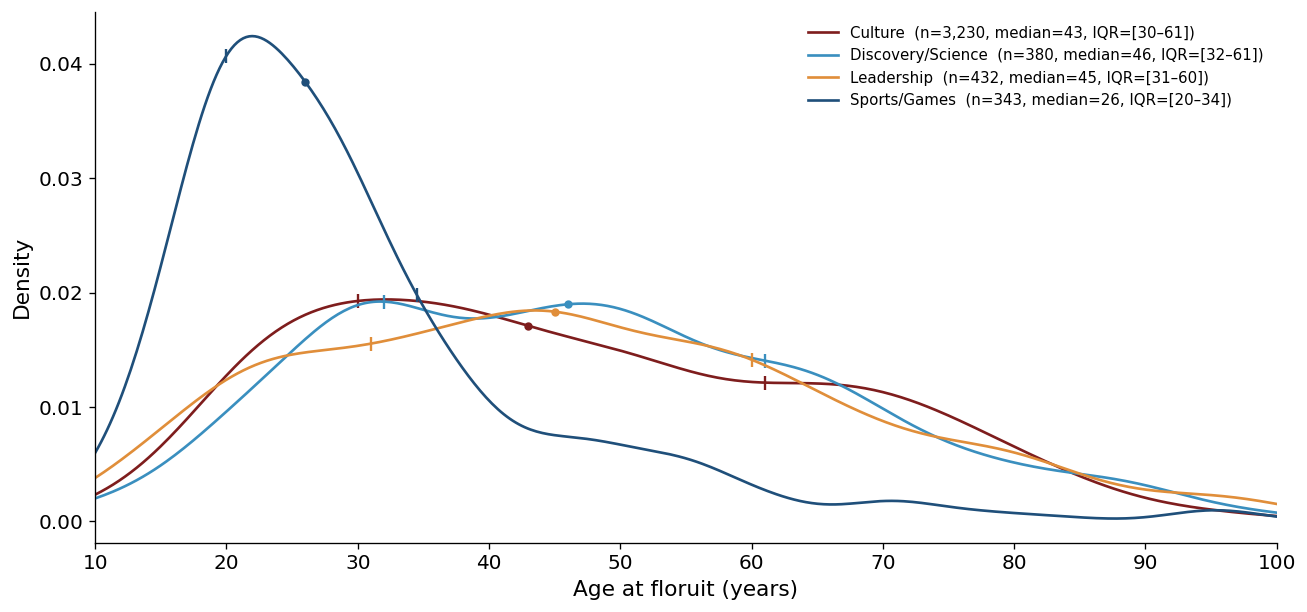

In [15]:
fig, ax = plt.subplots(figsize=(11, 5.2))
for occupation in SHOW_OCCUPATIONS:
    sub = age_at_floruit_by_occupation.filter(
        pl.col('level1_main_occ') == occupation
    )['age_at_floruit'].to_numpy()
    if len(sub) < 5:
        continue
    color = OCCUPATION_COLORS[occupation]
    kde = gaussian_kde(sub, bw_method=KDE_BANDWIDTH)
    y = kde(x_grid)
    median        = float(np.median(sub))
    quartile_low  = float(np.quantile(sub, 0.25))
    quartile_high = float(np.quantile(sub, 0.75))
    ax.plot(x_grid, y, color=color, lw=1.6,
            label=f'{occupation}  (n={len(sub):,}, median={median:.0f}, IQR=[{quartile_low:.0f}–{quartile_high:.0f}])')
    ax.plot([median], [kde(median)[0]], 'o', color=color, markersize=4)
    ax.plot([quartile_low, quartile_high],
            [kde(quartile_low)[0], kde(quartile_high)[0]],
            '|', color=color, markersize=8, markeredgewidth=1.4)

ax.set_xlim(AGE_MIN, AGE_MAX)
ax.set_xlabel('Age at floruit (years)')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()


## Median + IQR per century  (overall)

In [16]:
CENTURY_BIN_AGE = 100
MIN_BIN_N       = 5
LAST_X          = 2000

age_per_century = (
    age_at_floruit
    .with_columns(
        ((pl.col('floruit_year') // CENTURY_BIN_AGE) * CENTURY_BIN_AGE).cast(pl.Int64).alias('bin')
    )
    .group_by('bin')
    .agg(
        pl.len().alias('n'),
        pl.col('age_at_floruit').median().alias('median'),
        pl.col('age_at_floruit').quantile(0.25).alias('q25'),
        pl.col('age_at_floruit').quantile(0.75).alias('q75'),
    )
    .filter(pl.col('n') >= MIN_BIN_N)
    .sort('bin')
)

print('shape:', age_per_century.shape)
age_per_century.head()


shape: (27, 5)


bin,n,median,q25,q75
i64,u32,f64,f64,f64
-600,12,53.0,42.0,70.0
-500,16,67.0,31.0,81.0
-400,21,62.0,33.0,77.0
-300,15,42.0,30.0,56.0
-200,16,54.5,43.0,62.0


## Fig 5 — Age at floruit, median + IQR over centuries

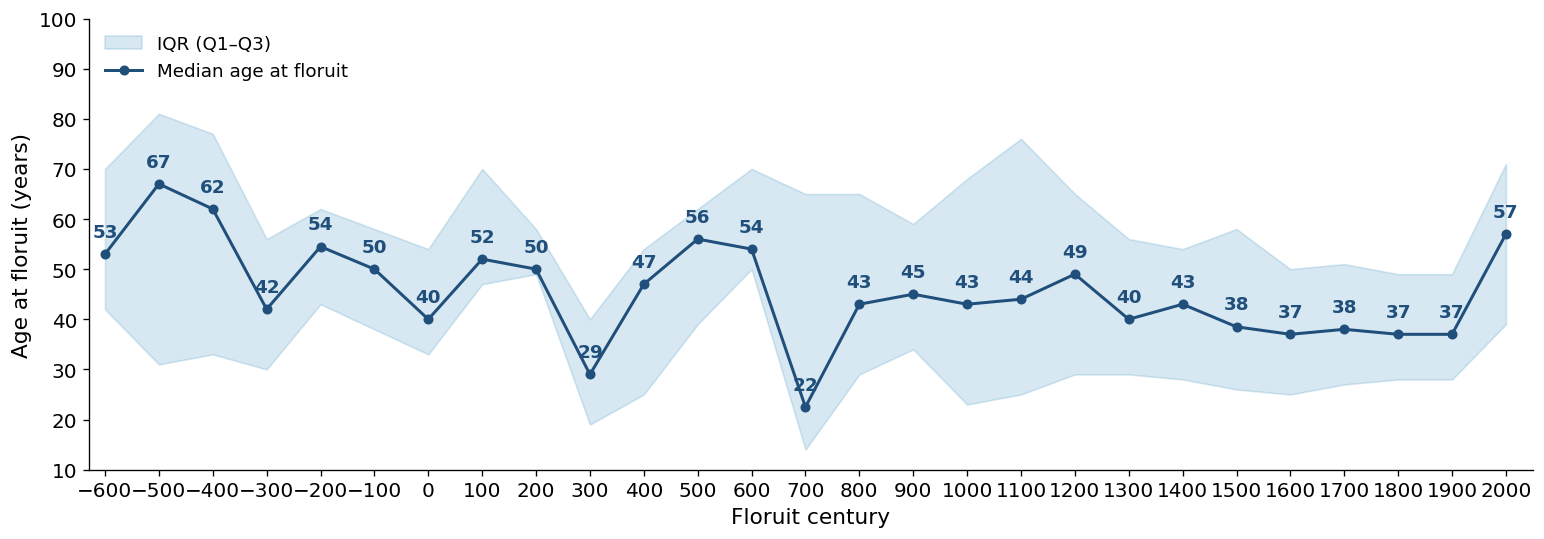

In [17]:
xs       = age_per_century['bin'].to_numpy().astype(float)
median   = age_per_century['median'].to_numpy()
q25      = age_per_century['q25'].to_numpy()
q75      = age_per_century['q75'].to_numpy()

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.fill_between(xs, q25, q75, color=COLORS['iqr_band'], alpha=0.20, label='IQR (Q1–Q3)')
ax.plot(xs, median, color=COLORS['median_line'], lw=1.8, marker='o', ms=5,
        label='Median age at floruit')
for x, m in zip(xs, median):
    ax.annotate(f'{m:.0f}', (x, m), xytext=(0, 8), textcoords='offset points',
                ha='center', va='bottom', fontsize=11,
                color=COLORS['median_line'], fontweight='bold')

ax.set_xlim(float(xs[0]) - CENTURY_BIN_AGE * 0.3, LAST_X + CENTURY_BIN_AGE / 2)
ax.set_xticks(list(range(int(xs[0]), LAST_X + 1, CENTURY_BIN_AGE)))
ax.set_ylim(AGE_MIN, AGE_MAX)
ax.set_ylabel('Age at floruit (years)')
ax.set_xlabel('Floruit century')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()


## Median + IQR per century, per CV occupation

In [18]:
age_per_century_by_occupation = (
    age_at_floruit_by_occupation
    .with_columns(
        ((pl.col('floruit_year') // CENTURY_BIN_AGE) * CENTURY_BIN_AGE).cast(pl.Int64).alias('bin')
    )
    .group_by('level1_main_occ', 'bin')
    .agg(
        pl.len().alias('n'),
        pl.col('age_at_floruit').median().alias('median'),
        pl.col('age_at_floruit').quantile(0.25).alias('q25'),
        pl.col('age_at_floruit').quantile(0.75).alias('q75'),
    )
    .filter(pl.col('n') >= MIN_BIN_N)
    .sort(['level1_main_occ', 'bin'])
)

print('shape:', age_per_century_by_occupation.shape)
age_per_century_by_occupation.head()


shape: (41, 6)


level1_main_occ,bin,n,median,q25,q75
str,i64,u32,f64,f64,f64
"""Culture""",-600,5,36.0,19.0,51.0
"""Culture""",1100,6,37.0,26.0,69.0
"""Culture""",1200,6,24.5,18.0,50.0
"""Culture""",1300,18,35.5,25.0,44.0
"""Culture""",1400,49,42.0,23.0,54.0


## Fig 6 — Age at floruit, median + IQR over centuries, per CV occupation

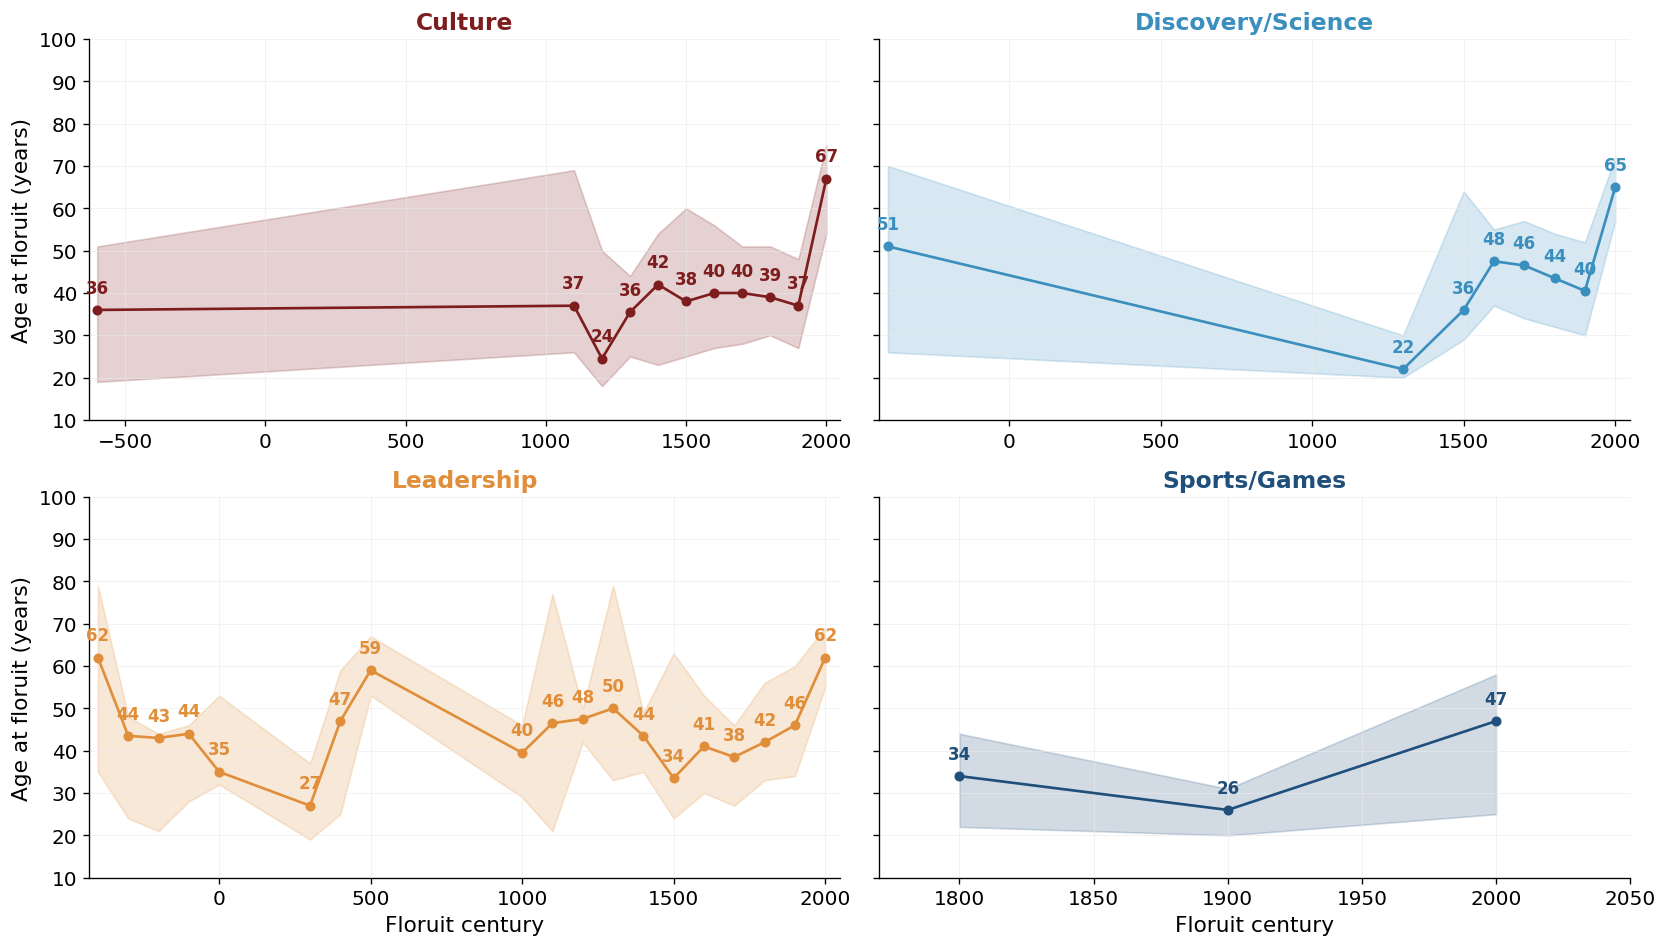

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
axes_flat = axes.flatten()

for ax, occupation in zip(axes_flat, SHOW_OCCUPATIONS):
    sub = age_per_century_by_occupation.filter(pl.col('level1_main_occ') == occupation).sort('bin')
    if sub.height == 0:
        ax.set_title(occupation, fontsize=14, color=OCCUPATION_COLORS[occupation], fontweight='bold')
        continue

    xs     = sub['bin'].to_numpy().astype(float)
    median = sub['median'].to_numpy()
    q25    = sub['q25'].to_numpy()
    q75    = sub['q75'].to_numpy()
    color  = OCCUPATION_COLORS[occupation]

    ax.fill_between(xs, q25, q75, color=color, alpha=0.20)
    ax.plot(xs, median, color=color, lw=1.6, marker='o', ms=5)
    for x, m in zip(xs, median):
        ax.annotate(f'{m:.0f}', (x, m),
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', va='bottom', fontsize=10, color=color, fontweight='bold')

    ax.set_xlim(float(xs[0]) - CENTURY_BIN_AGE * 0.3, LAST_X + CENTURY_BIN_AGE / 2)
    ax.set_ylim(AGE_MIN, AGE_MAX)
    ax.set_title(occupation, fontsize=14, color=color, fontweight='bold')
    ax.grid(True, color='#eaeaea', linewidth=0.6, alpha=0.6)

for ax in axes[:, 0]:
    ax.set_ylabel('Age at floruit (years)')
for ax in axes[-1, :]:
    ax.set_xlabel('Floruit century')

plt.tight_layout()
plt.show()


## Close

In [20]:
con.close()
